# J05 — Écoulement non saturé permanent et introduction à HYDRUS-1D

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 5 : fonctions hydrauliques, profils permanents, lecture d'un projet HYDRUS-1D, infiltromètre à disque*

> Version **instructeur** : code complet et résultats.

## Mise en place

Les projets HYDRUS-1D de référence sont dans `../../hydrus/` et se lisent avec le module `hydrus_io.py` (dossier `notebooks/`).
Unités du cours : **cm** et **jours** ; flux **positifs vers le haut** (convention HYDRUS-1D) ; profondeurs négatives.
Exécutez la cellule suivante pour importer les bibliothèques et définir la table des sols de Carsel & Parrish (1988).

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from hydrus_io import read_tlevel, read_nod_inf, read_obs_node, read_balance, read_run_inf

HYD = "../../hydrus"     # dossier des projets HYDRUS-1D

# sols de Carsel & Parrish (1988) : thr, ths (-), alpha (1/cm), n (-), Ks (cm/j) ; l = 0,5 pour tous
sols = pd.DataFrame(index=["sable", "loam sableux", "loam", "loam limoneux", "argile"])
sols["thr"] = [0.045, 0.065, 0.078, 0.067, 0.068]
sols["ths"] = [0.430, 0.410, 0.430, 0.450, 0.380]
sols["alpha"] = [0.145, 0.075, 0.036, 0.020, 0.008]
sols["n"] = [2.68, 1.89, 1.56, 1.41, 1.09]
sols["Ks"] = [712.8, 106.1, 24.96, 10.80, 4.80]
print(sols)

                 thr   ths  alpha     n      Ks
sable          0.045  0.43  0.145  2.68  712.80
loam sableux   0.065  0.41  0.075  1.89  106.10
loam           0.078  0.43  0.036  1.56   24.96
loam limoneux  0.067  0.45  0.020  1.41   10.80
argile         0.068  0.38  0.008  1.09    4.80


## Exercice 1 — Fonctions hydrauliques de Mualem–van Genuchten  *(≈ 15 min)*

1. Écrire les fonctions `vg_theta(h, thr, ths, alpha, n)`, `vg_K(h, thr, ths, alpha, n, Ks)` et `vg_C(h, thr, ths, alpha, n)`
   (valables pour $h \le 0$, avec $l = 0{,}5$) :
   $S_e = [1+(\alpha|h|)^n]^{-m}$, $m = 1-1/n$ ; $\theta = \theta_r + (\theta_s-\theta_r)S_e$ ;
   $K = K_s S_e^{l}[1-(1-S_e^{1/m})^m]^2$ ; $C = (\theta_s-\theta_r)\,\alpha n m (\alpha|h|)^{n-1}[1+(\alpha|h|)^n]^{-m-1}$.
   Vérifier le loam : $K(-50) \approx 0{,}258$ cm/j, $K(-500) \approx 1{,}7\times10^{-4}$ cm/j.
2. Tracer $K(h)$ et $C(h)$ en fonction de $|h|$ (échelles log-log) pour le sable, le loam et l'argile, puis $D(\theta) = K/C$ (échelle log en $y$).
3. Calculer la longueur capillaire macroscopique $\lambda_c = K_s^{-1}\int_{-\infty}^{0} K(h)\,dh$ pour les cinq sols
   (trapèzes sur une grille logarithmique de $|h|$, `np.trapezoid`) et $\alpha_G = 1/\lambda_c$. Vérifier le loam : $\lambda_c \approx 6{,}9$ cm.

**1. Fonctions de van Genuchten et Mualem**

In [2]:
# teneur en eau de van Genuchten (1980), h <= 0 : Se = [1 + (alpha |h|)^n]^(-m), m = 1 - 1/n
def vg_theta(h, thr, ths, alpha, n):
    m = 1 - 1 / n
    Se = (1 + (alpha * np.abs(h)) ** n) ** (-m)
    theta = thr + (ths - thr) * Se
    return theta

# conductivité hydraulique de Mualem–van Genuchten (cm/j), l = 0,5
def vg_K(h, thr, ths, alpha, n, Ks):
    m = 1 - 1 / n
    Se = (1 + (alpha * np.abs(h)) ** n) ** (-m)
    K = Ks * Se ** 0.5 * (1 - (1 - Se ** (1 / m)) ** m) ** 2
    return K

# capacité capillaire C = d theta / dh (1/cm)
def vg_C(h, thr, ths, alpha, n):
    m = 1 - 1 / n
    ah = alpha * np.abs(h)
    C = (ths - thr) * alpha * n * m * ah ** (n - 1) * (1 + ah ** n) ** (-m - 1)
    return C

# vérification sur le loam
thr = sols.loc["loam", "thr"]
ths = sols.loc["loam", "ths"]
alpha = sols.loc["loam", "alpha"]
n = sols.loc["loam", "n"]
Ks = sols.loc["loam", "Ks"]
print(f"loam : K(-50) = {vg_K(-50, thr, ths, alpha, n, Ks):.4f} cm/j")
print(f"loam : K(-500) = {vg_K(-500, thr, ths, alpha, n, Ks):.3e} cm/j")
print(f"loam : theta(-50) = {vg_theta(-50, thr, ths, alpha, n):.3f}")

loam : K(-50) = 0.2577 cm/j
loam : K(-500) = 1.707e-04 cm/j
loam : theta(-50) = 0.302


**2. Courbes K(h), C(h) et D(θ)**

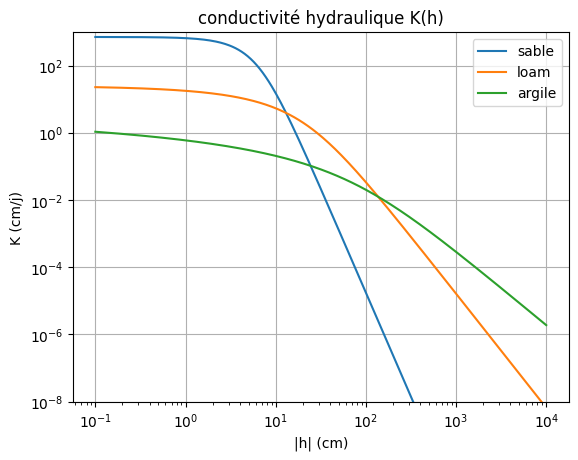

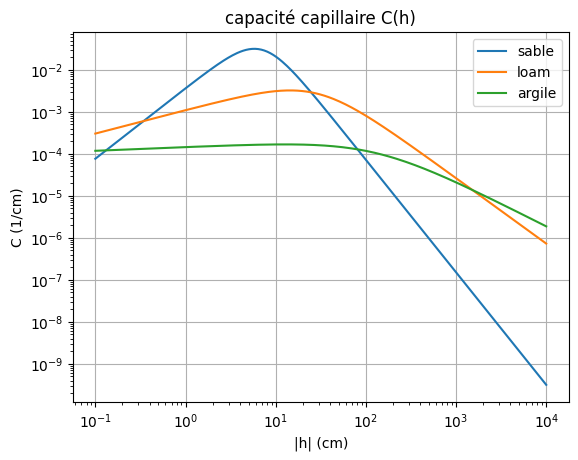

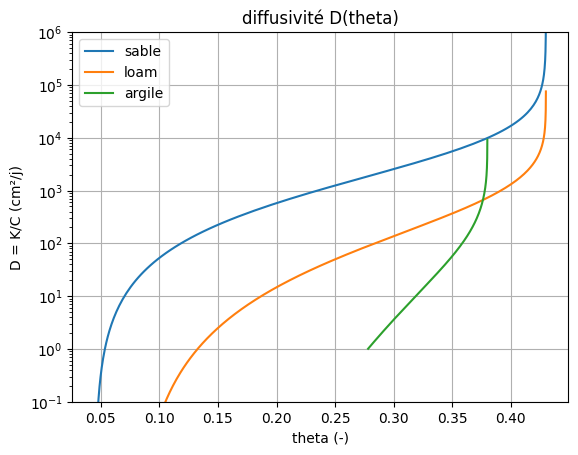

In [3]:
h_abs = np.logspace(-1, 4, 300)     # |h| de 0,1 à 10 000 cm, grille logarithmique
h_grille = -h_abs

plt.figure()
for nom in ["sable", "loam", "argile"]:
    s = sols.loc[nom]
    K = vg_K(h_grille, s["thr"], s["ths"], s["alpha"], s["n"], s["Ks"])
    plt.loglog(h_abs, K, label=nom)
plt.ylim(1e-8, 1e3)
plt.xlabel("|h| (cm)")
plt.ylabel("K (cm/j)")
plt.title("conductivité hydraulique K(h)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for nom in ["sable", "loam", "argile"]:
    s = sols.loc[nom]
    C = vg_C(h_grille, s["thr"], s["ths"], s["alpha"], s["n"])
    plt.loglog(h_abs, C, label=nom)
plt.xlabel("|h| (cm)")
plt.ylabel("C (1/cm)")
plt.title("capacité capillaire C(h)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for nom in ["sable", "loam", "argile"]:
    s = sols.loc[nom]
    theta = vg_theta(h_grille, s["thr"], s["ths"], s["alpha"], s["n"])
    K = vg_K(h_grille, s["thr"], s["ths"], s["alpha"], s["n"], s["Ks"])
    C = vg_C(h_grille, s["thr"], s["ths"], s["alpha"], s["n"])
    D = K / C
    plt.semilogy(theta, D, label=nom)
plt.ylim(1e-1, 1e6)
plt.xlabel("theta (-)")
plt.ylabel("D = K/C (cm²/j)")
plt.title("diffusivité D(theta)")
plt.legend()
plt.grid(True)
plt.show()

**3. Longueur capillaire macroscopique**

In [4]:
h_abs = np.logspace(-2, 4, 2000)     # grille logarithmique de |h| : 0,01 à 10 000 cm
lambda_c = []
alpha_G = []
theta_100 = []
K_100 = []
for nom in sols.index:
    s = sols.loc[nom]
    K = vg_K(-h_abs, s["thr"], s["ths"], s["alpha"], s["n"], s["Ks"])
    # intégrale de K/Ks par trapèzes, plus le segment [0 ; 0,01 cm] où K = Ks
    lc = np.trapezoid(K / s["Ks"], h_abs) + 0.01
    lambda_c.append(lc)
    alpha_G.append(1 / lc)
    theta_100.append(vg_theta(-100, s["thr"], s["ths"], s["alpha"], s["n"]))
    K_100.append(vg_K(-100, s["thr"], s["ths"], s["alpha"], s["n"], s["Ks"]))
sols["lambda_c"] = lambda_c
sols["alpha_G"] = alpha_G
sols["theta_100"] = theta_100
sols["K_100"] = K_100
print(sols.round(4))

                 thr   ths  alpha     n      Ks  lambda_c  alpha_G  theta_100  \
sable          0.045  0.43  0.145  2.68  712.80    3.8081   0.2626     0.0493   
loam sableux   0.065  0.41  0.075  1.89  106.10    4.9666   0.2013     0.1218   
loam           0.078  0.43  0.036  1.56   24.96    6.9205   0.1445     0.2421   
loam limoneux  0.067  0.45  0.020  1.41   10.80    8.9520   0.1117     0.3297   
argile         0.068  0.38  0.008  1.09    4.80    2.4526   0.4077     0.3654   

                K_100  
sable          0.0000  
loam sableux   0.0046  
loam           0.0339  
loam limoneux  0.0704  
argile         0.0202  


**Commentaire (instructeur).** $K$ chute de 8 à 10 ordres de grandeur entre la saturation et $|h| = 10^4$ cm ; les courbes se croisent vers $|h| \approx 30$–100 cm :
au-delà, le sable est moins conducteur que l'argile. $\lambda_c$ croît du sable (3,8 cm) au loam limoneux (9 cm) : la capillarité
gagne en importance dans les sols fins. La valeur MvG de l'argile ($n = 1{,}09$) est peu réaliste (queue de $K$ très longue, $K_r$
non intégrable en pratique) : c'est une limite connue du modèle pour $n < 1{,}2$.

## Exercice 2 — Profils permanents au-dessus d'une nappe et évaporation maximale  *(≈ 20 min)*

En régime permanent le flux $q$ est constant et $\dfrac{dh}{dz} = -1 - \dfrac{q}{K(h)}$ ($z$ vers le haut, $q > 0$ vers le haut).
On intègre cette équation **depuis la nappe** ($h = 0$ en $z = -L$) vers la surface par petits pas $dz$ (schéma d'Euler) :
$h_{i+1} = h_i + \left(-1 - \dfrac{q}{K(h_i)}\right) dz$.

1. Loam, nappe à $L = 100$ cm, infiltration $q = -1$ cm/j : calculer le profil $h(z)$ avec $dz = 0{,}1$ cm et $h$ en surface
   (attendu $\approx -28{,}6$ cm).
2. Même calcul pour l'évaporation $q = +0{,}03$ cm/j (attendu $h \approx -138$ cm en surface).
3. Lire `NOD_INF.OUT` des projets `J05_permanent_nappe_infiltration` et `J05_permanent_nappe_evaporation` (`read_nod_inf`),
   extraire le profil à $t = 200$ j, le superposer à votre calcul et calculer l'écart RMS sur $h$ (HYDRUS : $h$ en surface
   $= -28{,}9$ cm et $-135{,}2$ cm).
4. Évaporation maximale : la profondeur de nappe maximale compatible avec un flux $q$ est
   $L_{max}(q) = \int_{-\infty}^{0} \dfrac{dh}{1 + q/K(h)} = \int_{-\infty}^{0} \dfrac{K}{K + q}\,dh$ (Gardner 1958).
   Calculer $L_{max}$ par trapèzes, puis $e_{max}$ (le $q$ tel que $L_{max}(q) = L$, `brentq`) pour le loam et $L = 100$ cm
   (attendu $\approx 0{,}054$ cm/j).
5. Tracer $e_{max}(L)$ pour $L$ de 30 à 300 cm pour le sable, le loam et le loam limoneux (échelles log) et estimer l'exposant
   de la loi de puissance $e_{max} \propto L^{-n}$ entre 70 et 200 cm.

**1. Profil d'infiltration permanente (q = −1 cm/j)**

In [5]:
# paramètres du loam
thr = sols.loc["loam", "thr"]
ths = sols.loc["loam", "ths"]
alpha = sols.loc["loam", "alpha"]
n = sols.loc["loam", "n"]
Ks = sols.loc["loam", "Ks"]

L = 100.0      # profondeur de la nappe (cm)
dz = 0.1       # pas d'intégration (cm)
n_pas = round(L / dz)
q = -1.0       # flux (cm/j), négatif = vers le bas (infiltration)

# départ à la nappe (z = -L, h = 0) ; on monte vers la surface pas à pas
z = -L
h = 0.0
z_inf = [z]
h_inf = [h]
for i in range(n_pas):
    K = vg_K(h, thr, ths, alpha, n, Ks)
    dh_dz = -1 - q / K
    h = h + dh_dz * dz
    z = z + dz
    z_inf.append(z)
    h_inf.append(h)
z_inf = np.array(z_inf)
h_inf = np.array(h_inf)

print(f"infiltration q = {q} cm/j : h en surface = {h_inf[-1]:.2f} cm")
print(f"h à 50 cm au-dessus de la nappe = {np.interp(-50, z_inf, h_inf):.2f} cm (gradient unitaire : K(h) = |q|)")

infiltration q = -1.0 cm/j : h en surface = -28.62 cm
h à 50 cm au-dessus de la nappe = -26.88 cm (gradient unitaire : K(h) = |q|)


**2. Profil d'évaporation permanente (q = +0,03 cm/j)**

In [6]:
q = 0.03       # flux (cm/j), positif = vers le haut (évaporation)

z = -L
h = 0.0
z_eva = [z]
h_eva = [h]
for i in range(n_pas):
    K = vg_K(h, thr, ths, alpha, n, Ks)
    dh_dz = -1 - q / K
    h = h + dh_dz * dz
    z = z + dz
    z_eva.append(z)
    h_eva.append(h)
z_eva = np.array(z_eva)
h_eva = np.array(h_eva)

print(f"évaporation q = {q} cm/j : h en surface = {h_eva[-1]:.2f} cm")

évaporation q = 0.03 cm/j : h en surface = -138.34 cm


**3. Comparaison avec les profils HYDRUS-1D à t = 200 j**

temps d'impression (j) : [0.0, 20.0, 40.0, 60.0, 80.0, 100.0, 120.0, 140.0, 160.0, 180.0, 200.0]
      Depth    Head  Moisture      K  Flux
Node                                      
1       0.0 -28.904    0.3495  1.002  -1.0
2      -1.0 -28.902    0.3495  1.002  -1.0
3      -2.0 -28.900    0.3495  1.002  -1.0
4      -3.0 -28.897    0.3495  1.003  -1.0
5      -4.0 -28.895    0.3495  1.003  -1.0
infiltration : h surface Euler = -28.62 cm, HYDRUS = -28.90 cm, écart RMS = 0.236 cm
évaporation : h surface Euler = -138.34 cm, HYDRUS = -135.18 cm, écart RMS = 0.792 cm


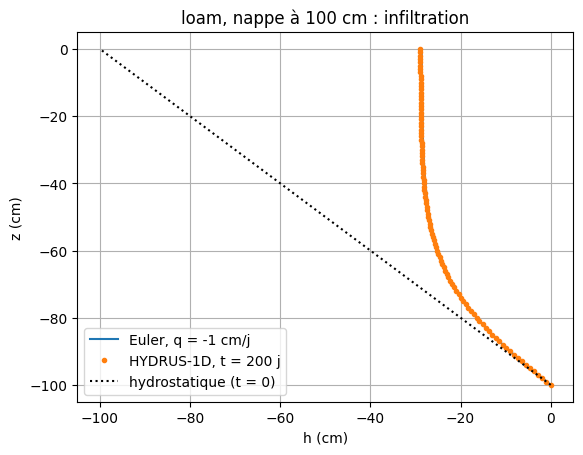

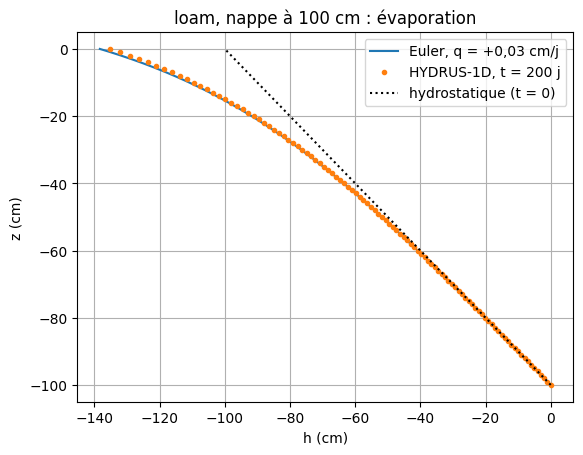

In [7]:
nod_inf = read_nod_inf(HYD + "/J05_permanent_nappe_infiltration")
nod_eva = read_nod_inf(HYD + "/J05_permanent_nappe_evaporation")
print("temps d'impression (j) :", list(nod_inf.keys()))
prof_inf = nod_inf[200.0]        # profil au dernier temps d'impression (régime permanent)
prof_eva = nod_eva[200.0]
print(prof_inf[["Depth", "Head", "Moisture", "K", "Flux"]].head())

# h en surface d'après HYDRUS (noeud 1, Depth = 0)
h_hyd_inf = prof_inf["Head"].iloc[0]
h_hyd_eva = prof_eva["Head"].iloc[0]

# profil calculé interpolé aux profondeurs des noeuds HYDRUS, puis écart RMS
h_calc_inf = np.interp(prof_inf["Depth"], z_inf, h_inf)
rms_inf = np.sqrt(np.mean((h_calc_inf - prof_inf["Head"]) ** 2))
h_calc_eva = np.interp(prof_eva["Depth"], z_eva, h_eva)
rms_eva = np.sqrt(np.mean((h_calc_eva - prof_eva["Head"]) ** 2))
print(f"infiltration : h surface Euler = {h_inf[-1]:.2f} cm, HYDRUS = {h_hyd_inf:.2f} cm, écart RMS = {rms_inf:.3f} cm")
print(f"évaporation : h surface Euler = {h_eva[-1]:.2f} cm, HYDRUS = {h_hyd_eva:.2f} cm, écart RMS = {rms_eva:.3f} cm")

plt.figure()
plt.plot(h_inf, z_inf, label="Euler, q = -1 cm/j")
plt.plot(prof_inf["Head"], prof_inf["Depth"], "o", markersize=3, label="HYDRUS-1D, t = 200 j")
plt.plot([0, -100], [-100, 0], "k:", label="hydrostatique (t = 0)")
plt.xlabel("h (cm)")
plt.ylabel("z (cm)")
plt.title("loam, nappe à 100 cm : infiltration")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(h_eva, z_eva, label="Euler, q = +0,03 cm/j")
plt.plot(prof_eva["Head"], prof_eva["Depth"], "o", markersize=3, label="HYDRUS-1D, t = 200 j")
plt.plot([0, -100], [-100, 0], "k:", label="hydrostatique (t = 0)")
plt.xlabel("h (cm)")
plt.ylabel("z (cm)")
plt.title("loam, nappe à 100 cm : évaporation")
plt.legend()
plt.grid(True)
plt.show()

**4. Évaporation maximale depuis une nappe à 100 cm (Gardner 1958)**

In [8]:
# profondeur maximale de nappe (cm) capable d'entretenir le flux q (cm/j) : L_max = intégrale de K/(K + q) dh
def L_max(q, thr, ths, alpha, n, Ks):
    h_abs = np.logspace(-2, 7, 4000)
    K = vg_K(-h_abs, thr, ths, alpha, n, Ks)
    L = np.trapezoid(K / (K + q), h_abs) + 0.01
    return L

# écart entre L_max(q) et la profondeur L de la nappe : il s'annule pour q = e_max
def ecart_L(q, L, thr, ths, alpha, n, Ks):
    return L_max(q, thr, ths, alpha, n, Ks) - L

for q in [0.01, 0.03, 0.05, 0.10]:
    print(f"loam, q = {q} cm/j : L_max = {L_max(q, thr, ths, alpha, n, Ks):.1f} cm")

# brentq cherche q entre 1e-12 et Ks tel que ecart_L = 0 ; args = les autres arguments de ecart_L
e_max_loam = brentq(ecart_L, 1e-12, Ks, args=(100.0, thr, ths, alpha, n, Ks))
print(f"e_max du loam, nappe à 100 cm : {e_max_loam:.4f} cm/j")

loam, q = 0.01 cm/j : L_max = 170.6 cm
loam, q = 0.03 cm/j : L_max = 121.1 cm
loam, q = 0.05 cm/j : L_max = 102.8 cm
loam, q = 0.1 cm/j : L_max = 81.8 cm
e_max du loam, nappe à 100 cm : 0.0545 cm/j


**5. Évaporation maximale en fonction de la profondeur de nappe**

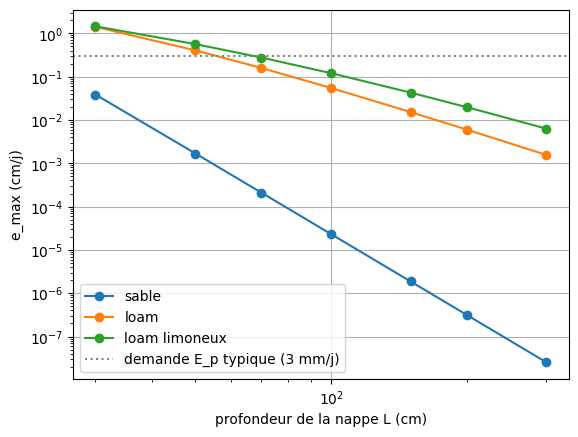

               sable      loam  loam limoneux
L (cm)                                       
30      3.846590e-02  1.405334       1.447097
50      1.676459e-03  0.402678       0.561293
70      2.096079e-04  0.158198       0.275310
100     2.302936e-05  0.054472       0.119773
150     1.866553e-06  0.015168       0.042694
200     3.137351e-07  0.005954       0.019648
300     2.540230e-08  0.001555       0.006291
sable : e_max ~ L^-6.2 entre 70 et 200 cm
loam : e_max ~ L^-3.1 entre 70 et 200 cm
loam limoneux : e_max ~ L^-2.5 entre 70 et 200 cm


In [9]:
Ls = np.array([30, 50, 70, 100, 150, 200, 300])     # profondeurs de nappe (cm)
tab = pd.DataFrame(index=Ls)
tab.index.name = "L (cm)"

plt.figure()
for nom in ["sable", "loam", "loam limoneux"]:
    s = sols.loc[nom]
    e_max = []
    for L in Ls:
        e = brentq(ecart_L, 1e-12, s["Ks"], args=(L, s["thr"], s["ths"], s["alpha"], s["n"], s["Ks"]))
        e_max.append(e)
    tab[nom] = e_max
    plt.loglog(Ls, e_max, "o-", label=nom)
plt.axhline(0.3, color="gray", linestyle=":", label="demande E_p typique (3 mm/j)")
plt.xlabel("profondeur de la nappe L (cm)")
plt.ylabel("e_max (cm/j)")
plt.legend()
plt.grid(True)
plt.show()
print(tab)

# exposant de la loi de puissance e_max ~ L^(-n) entre 70 et 200 cm (pente dans le plan log-log)
for nom in ["sable", "loam", "loam limoneux"]:
    pente = -(np.log(tab.loc[200, nom]) - np.log(tab.loc[70, nom])) / (np.log(200) - np.log(70))
    print(f"{nom} : e_max ~ L^-{pente:.1f} entre 70 et 200 cm")

**Commentaire (instructeur).** Pour l'infiltration, le profil devient vertical (gradient unitaire) dès 40–50 cm au-dessus de la nappe, à $h \approx -28{,}6$ cm
tel que $K(h) = 1$ cm/j ; HYDRUS donne $-28{,}9$ cm (moyenne arithmétique de $K$ entre nœuds près de la nappe). Pour l'évaporation à
0,03 cm/j la surface est à $-135$ cm. L'évaporation maximale du loam pour une nappe à 1 m ($\approx 0{,}054$ cm/j) est bien
inférieure à une demande de 3 mm/j : l'évaporation est limitée par le sol. La décroissance de $e_{max}$ suit une loi de puissance
$L^{-n}$ avec $n \approx 3$ pour le loam, comme prévu par Gardner (1958).

## Exercice 3 — Lecture d'un projet HYDRUS-1D : convergence vers le régime permanent  *(≈ 15 min)*

Les deux projets `J05_permanent_nappe_*` partent d'un profil hydrostatique ($h = -100 - z$, $H = -100$ cm) et imposent un flux constant
en surface (−1 cm/j ou +0,03 cm/j) avec une nappe fixe ($h = 0$) au bas d'une colonne de loam de 100 cm, pendant 200 j.

1. Lire `T_LEVEL.OUT` des deux projets (`read_tlevel`) et tracer `vTop` et `vBot` (flux en surface et au bas, > 0 vers le haut)
   en fonction du temps.
2. Déterminer $t_{99}$, premier instant où $|$`vBot` − `vTop`$| < 1$ % de $|q|$.
3. Tracer `hTop` (charge de pression en surface) en fonction du temps.
4. Lire `OBS_NODE.OUT` (`read_obs_node`) et tracer $h(t)$ aux nœuds d'observation (10, 30, 50 et 80 cm).
5. Lire `RUN_INF.OUT` (`read_run_inf`) : tracer $\Delta t$ en fonction du temps (échelle log) et l'histogramme du nombre
   d'itérations par pas ; compter les pas et les itérations totales.
6. Lire `BALANCE.OUT` (`read_balance`) : erreur relative maximale `WatBalR` (%) et variation du stock `W-volume` entre 0 et 200 j ;
   vérifier qu'elle est cohérente avec `sum(vBot)` − `sum(vTop)` de `T_LEVEL.OUT`
   ($\Delta W = \int (q_{bas} - q_{haut})\,dt$ avec $q > 0$ vers le haut).

**Lecture des fichiers T_LEVEL.OUT**

In [10]:
tl_inf = read_tlevel(HYD + "/J05_permanent_nappe_infiltration")
tl_eva = read_tlevel(HYD + "/J05_permanent_nappe_evaporation")
print("colonnes :", list(tl_inf.columns))
print(tl_eva[["rTop", "vTop", "vBot", "hTop", "hBot", "sum(vTop)", "sum(vBot)"]].head())

colonnes : ['rTop', 'rRoot', 'vTop', 'vRoot', 'vBot', 'sum(rTop)', 'sum(rRoot)', 'sum(vTop)', 'sum(vRoot)', 'sum(vBot)', 'hTop', 'hRoot', 'hBot', 'RunOff', 'sum(RunOff)', 'Volume', 'sum(Infil)', 'sum(Evap)', 'TLevel', 'Cum(WTrans)', 'SnowLayer']
        rTop      vTop      vBot    hTop  hBot  sum(vTop)     sum(vBot)
Time                                                                   
0.0100  0.03  0.029999 -0.000004 -100.48   0.0   0.000300 -3.824100e-08
0.0200  0.03  0.030000  0.000000 -100.79   0.0   0.000600 -3.824100e-08
0.0330  0.03  0.030000 -0.000001 -101.09   0.0   0.000990 -5.481300e-08
0.0499  0.03  0.030000 -0.000001 -101.38   0.0   0.001497 -7.635500e-08
0.0719  0.03  0.030000 -0.000001 -101.69   0.0   0.002156 -1.043600e-07


**1. Flux en surface et au bas de la colonne**

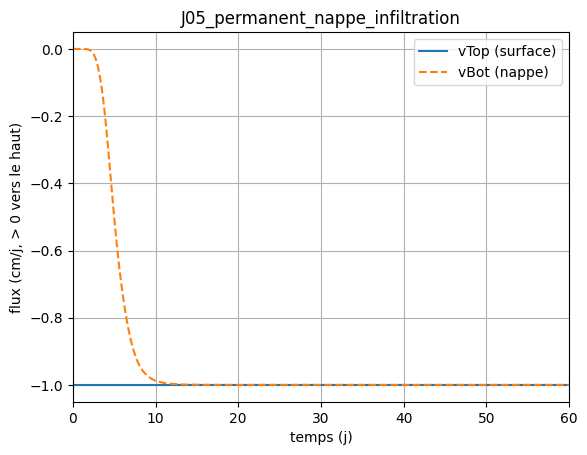

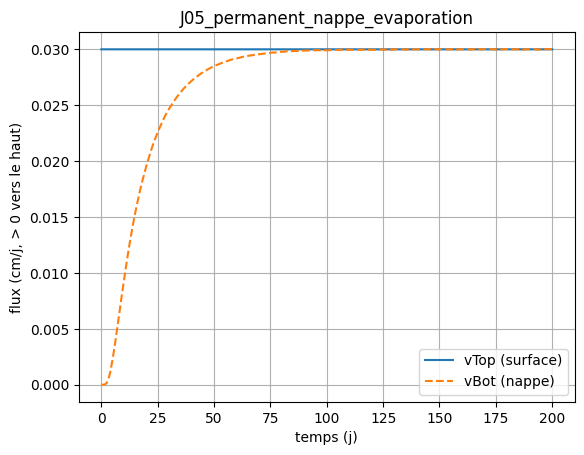

In [11]:
plt.figure()
plt.plot(tl_inf.index, tl_inf["vTop"], label="vTop (surface)")
plt.plot(tl_inf.index, tl_inf["vBot"], "--", label="vBot (nappe)")
plt.xlim(0, 60)
plt.xlabel("temps (j)")
plt.ylabel("flux (cm/j, > 0 vers le haut)")
plt.title("J05_permanent_nappe_infiltration")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(tl_eva.index, tl_eva["vTop"], label="vTop (surface)")
plt.plot(tl_eva.index, tl_eva["vBot"], "--", label="vBot (nappe)")
plt.xlabel("temps (j)")
plt.ylabel("flux (cm/j, > 0 vers le haut)")
plt.title("J05_permanent_nappe_evaporation")
plt.legend()
plt.grid(True)
plt.show()

**2. Temps d'atteinte du régime permanent t99**

In [12]:
# infiltration : flux imposé q = rTop ; écart entre les flux au bas et en surface
q_inf = tl_inf["rTop"].iloc[-1]
temps = tl_inf.index.to_numpy()
ecart = np.abs(tl_inf["vBot"].to_numpy() - tl_inf["vTop"].to_numpy())
seuil = 0.01 * abs(q_inf)
instants = temps[ecart < seuil]       # tous les instants où l'écart est sous 1 % de |q|
t99_inf = instants[0]
print(f"infiltration : q = {q_inf} cm/j, t99 = {t99_inf} j")

# évaporation
q_eva = tl_eva["rTop"].iloc[-1]
temps = tl_eva.index.to_numpy()
ecart = np.abs(tl_eva["vBot"].to_numpy() - tl_eva["vTop"].to_numpy())
seuil = 0.01 * abs(q_eva)
instants = temps[ecart < seuil]
t99_eva = instants[0]
print(f"évaporation : q = {q_eva} cm/j, t99 = {t99_eva} j")

infiltration : q = -1.0 cm/j, t99 = 11.0 j
évaporation : q = 0.03 cm/j, t99 = 76.0 j


**3. Charge de pression en surface**

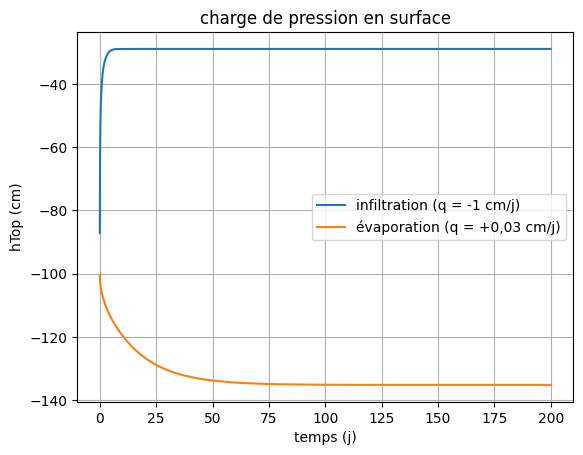

hTop à 200 j : infiltration -28.90 cm, évaporation -135.18 cm


In [13]:
plt.figure()
plt.plot(tl_inf.index, tl_inf["hTop"], label="infiltration (q = -1 cm/j)")
plt.plot(tl_eva.index, tl_eva["hTop"], label="évaporation (q = +0,03 cm/j)")
plt.xlabel("temps (j)")
plt.ylabel("hTop (cm)")
plt.title("charge de pression en surface")
plt.legend()
plt.grid(True)
plt.show()

hTop_inf = tl_inf["hTop"].iloc[-1]
hTop_eva = tl_eva["hTop"].iloc[-1]
print(f"hTop à 200 j : infiltration {hTop_inf:.2f} cm, évaporation {hTop_eva:.2f} cm")

**4. Charges de pression aux nœuds d'observation (OBS_NODE.OUT)**

node     11                  31                 51                  81  \
var       h   theta  Temp     h  theta  Temp     h   theta  Temp     h   
Time                                                                     
0.010 -90.0  0.2513  20.0 -70.0  0.273  20.0 -50.0  0.3029  20.0 -20.0   
0.020 -90.0  0.2513  20.0 -70.0  0.273  20.0 -50.0  0.3029  20.0 -20.0   
0.033 -90.0  0.2513  20.0 -70.0  0.273  20.0 -50.0  0.3029  20.0 -20.0   

node                 
var     theta  Temp  
Time                 
0.010  0.3755  20.0  
0.020  0.3755  20.0  
0.033  0.3755  20.0  


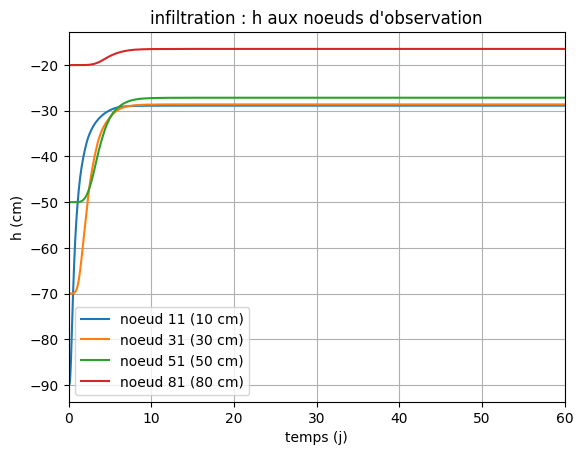

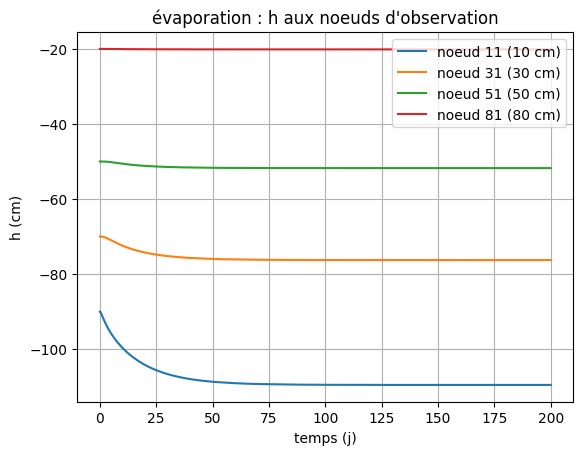

In [14]:
obs_inf = read_obs_node(HYD + "/J05_permanent_nappe_infiltration")
obs_eva = read_obs_node(HYD + "/J05_permanent_nappe_evaporation")
print(obs_eva.head(3))

# noeuds 11, 31, 51, 81 = profondeurs 10, 30, 50, 80 cm (dz = 1 cm, noeud 1 en surface)
plt.figure()
for noeud in [11, 31, 51, 81]:
    plt.plot(obs_inf.index, obs_inf[(noeud, "h")], label=f"noeud {noeud} ({noeud - 1} cm)")
plt.xlim(0, 60)
plt.xlabel("temps (j)")
plt.ylabel("h (cm)")
plt.title("infiltration : h aux noeuds d'observation")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
for noeud in [11, 31, 51, 81]:
    plt.plot(obs_eva.index, obs_eva[(noeud, "h")], label=f"noeud {noeud} ({noeud - 1} cm)")
plt.xlabel("temps (j)")
plt.ylabel("h (cm)")
plt.title("évaporation : h aux noeuds d'observation")
plt.legend()
plt.grid(True)
plt.show()

**5. Pas de temps et itérations (RUN_INF.OUT)**

   TLevel  Time    dt  Iter  ItCum  KodT  KodB  Convergency
0     1.0  0.01  0.01   6.0    6.0  -1.0   1.0         True
1     2.0  0.02  0.01   5.0   11.0  -1.0   1.0         True
2     3.0  0.03  0.01   4.0   15.0  -1.0   1.0         True


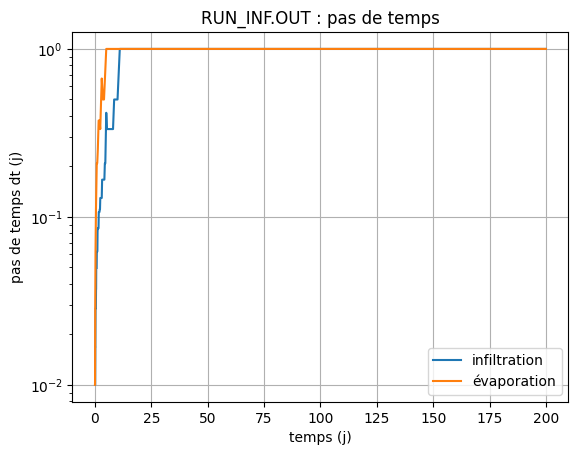

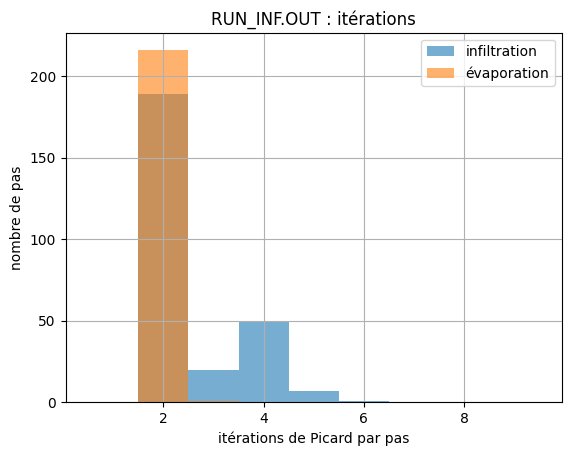

infiltration : 266 pas, 675 itérations (2.54 par pas), dt de 0.01 à 1.0 j
évaporation : 217 pas, 435 itérations (2.00 par pas), dt de 0.01 à 1.0 j


In [15]:
ri_inf = read_run_inf(HYD + "/J05_permanent_nappe_infiltration")
ri_eva = read_run_inf(HYD + "/J05_permanent_nappe_evaporation")
print(ri_inf.head(3))

plt.figure()
plt.semilogy(ri_inf["Time"], ri_inf["dt"], label="infiltration")
plt.semilogy(ri_eva["Time"], ri_eva["dt"], label="évaporation")
plt.xlabel("temps (j)")
plt.ylabel("pas de temps dt (j)")
plt.title("RUN_INF.OUT : pas de temps")
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.hist(ri_inf["Iter"], bins=np.arange(0.5, 10.5, 1), alpha=0.6, label="infiltration")     # alpha = transparence
plt.hist(ri_eva["Iter"], bins=np.arange(0.5, 10.5, 1), alpha=0.6, label="évaporation")
plt.xlabel("itérations de Picard par pas")
plt.ylabel("nombre de pas")
plt.title("RUN_INF.OUT : itérations")
plt.legend()
plt.grid(True)
plt.show()

# nombre de pas, itérations totales et moyennes, pas de temps min et max
n_pas_inf = len(ri_inf)
iter_total_inf = ri_inf["Iter"].sum()
iter_moy_inf = ri_inf["Iter"].mean()
print(f"infiltration : {n_pas_inf} pas, {iter_total_inf:.0f} itérations ({iter_moy_inf:.2f} par pas), dt de {ri_inf['dt'].min()} à {ri_inf['dt'].max()} j")
n_pas_eva = len(ri_eva)
iter_total_eva = ri_eva["Iter"].sum()
iter_moy_eva = ri_eva["Iter"].mean()
print(f"évaporation : {n_pas_eva} pas, {iter_total_eva:.0f} itérations ({iter_moy_eva:.2f} par pas), dt de {ri_eva['dt'].min()} à {ri_eva['dt'].max()} j")

**6. Bilan de masse (BALANCE.OUT)**

In [16]:
bal_inf = read_balance(HYD + "/J05_permanent_nappe_infiltration")
bal_eva = read_balance(HYD + "/J05_permanent_nappe_evaporation")
print(bal_eva[["W-volume", "Top Flux", "Bot Flux", "WatBalT", "WatBalR"]])

# erreur relative maximale de bilan (%)
WatBalR_inf = bal_inf["WatBalR"].abs().max()
WatBalR_eva = bal_eva["WatBalR"].abs().max()
print(f"WatBalR max : infiltration {WatBalR_inf:.3f} %, évaporation {WatBalR_eva:.3f} %")

# variation du stock d'eau entre 0 et 200 j (cm) d'après BALANCE.OUT
W0_inf = bal_inf["W-volume"].iloc[0]
W200_inf = bal_inf["W-volume"].iloc[-1]
dW_bilan_inf = W200_inf - W0_inf
W0_eva = bal_eva["W-volume"].iloc[0]
W200_eva = bal_eva["W-volume"].iloc[-1]
dW_bilan_eva = W200_eva - W0_eva

# d'après les flux cumulés de T_LEVEL.OUT : dW = sum(vBot) - sum(vTop)  (q > 0 vers le haut)
dW_flux_inf = tl_inf["sum(vBot)"].iloc[-1] - tl_inf["sum(vTop)"].iloc[-1]
dW_flux_eva = tl_eva["sum(vBot)"].iloc[-1] - tl_eva["sum(vTop)"].iloc[-1]

print(f"infiltration : W0 = {W0_inf:.3f} cm, W200 = {W200_inf:.3f} cm, dW = {dW_bilan_inf:.3f} cm (BALANCE) et {dW_flux_inf:.3f} cm (flux cumulés)")
print(f"évaporation : W0 = {W0_eva:.3f} cm, W200 = {W200_eva:.3f} cm, dW = {dW_bilan_eva:.3f} cm (BALANCE) et {dW_flux_eva:.3f} cm (flux cumulés)")

       W-volume  Top Flux  Bot Flux   WatBalT  WatBalR
Time                                                  
0.0      31.631 -0.000000 -0.000000       NaN      NaN
20.0     31.222  0.029857  0.019583 -0.000066    0.008
40.0     31.110  0.029957  0.027156 -0.000169    0.009
60.0     31.079  0.029987  0.029185 -0.000151    0.005
80.0     31.070  0.029996  0.029784 -0.000240    0.006
100.0    31.068  0.029999  0.029919 -0.000364    0.007
120.0    31.067  0.030000  0.029965 -0.000296    0.004
140.0    31.067  0.030000  0.029993 -0.000234    0.003
160.0    31.067  0.030000  0.029993 -0.000298    0.003
180.0    31.066  0.030000  0.030011 -0.000349    0.003
200.0    31.066  0.030000  0.030011 -0.000368    0.003
WatBalR max : infiltration 0.000 %, évaporation 0.009 %
infiltration : W0 = 31.631 cm, W200 = 36.719 cm, dW = 5.088 cm (BALANCE) et 5.090 cm (flux cumulés)
évaporation : W0 = 31.631 cm, W200 = 31.066 cm, dW = -0.565 cm (BALANCE) et -0.564 cm (flux cumulés)


**Commentaire (instructeur).** Le régime permanent (à 1 % près) est atteint en ~11 j pour l'infiltration (l'eau infiltrée traverse un sol déjà humide) mais en
~75 j pour l'évaporation, car la diffusivité du sol qui sèche est très faible. Le pas de temps croît de 0,01 j à 1 j (borné par
l'intervalle d'impression de 20 j et par dtMax), avec 2 à 6 itérations de Picard par pas. L'erreur de bilan `WatBalR` reste
inférieure à 0,01 % et la variation de stock (+5,1 cm en infiltration, −0,6 cm en évaporation) est retrouvée à partir des flux
cumulés de `T_LEVEL.OUT`.

## Exercice 4 — Infiltromètre à disque : Wooding et méthode à deux tensions  *(≈ 10 min)*

`data/J05_infiltrometre.csv` : pour quatre sites (textures indiquées), débits permanents $Q$ (cm³/min) mesurés avec un disque de rayon
$r = 10$ cm aux tensions $h_0 = -3$ cm et $-10$ cm.

Solution de Wooding (1968) avec $K = K_s e^{\alpha_G h}$ : $Q = \pi r^2 K(h_0)\left(1 + \dfrac{4}{\pi r \alpha_G}\right)$.

1. Pour chaque site, calculer $\alpha_G = \ln(Q_1/Q_2)/(h_1 - h_2)$, $\lambda_c = 1/\alpha_G$, puis $K_s$ (convertir $Q$ en cm³/j).
2. Calculer la part du débit due à la capillarité latérale, $\dfrac{4/(\pi r\alpha_G)}{1 + 4/(\pi r\alpha_G)}$, à $h_0 = -3$ cm.
3. Comparer $K_s$ et $\lambda_c$ aux valeurs de Carsel & Parrish de la texture (exercice 1) ; commenter les écarts.

**Lecture des données**

In [17]:
inf = pd.read_csv("data/J05_infiltrometre.csv")
print(inf)

  site        texture  r_cm  Q_h3_cm3min  Q_h10_cm3min
0    A          sable  10.0       63.109         8.708
1    B   loam sableux  10.0       24.901         4.931
2    C           loam  10.0        8.078         3.474
3    D  loam limoneux  10.0        2.704         1.171


**1. Paramètres de Gardner par la méthode à deux tensions**

In [18]:
h1 = -3.0       # première tension (cm)
h2 = -10.0      # seconde tension (cm)
Q1 = inf["Q_h3_cm3min"] * 1440      # débit à h1, converti en cm³/j
Q2 = inf["Q_h10_cm3min"] * 1440     # débit à h2, cm³/j
r = inf["r_cm"]

# alpha_G (1/cm) et longueur capillaire (cm) : le rapport des débits ne dépend que de alpha_G
inf["alpha_G"] = np.log(Q1 / Q2) / (h1 - h2)
inf["lambda_c"] = 1 / inf["alpha_G"]

# facteur géométrique de Wooding, puis Ks en extrapolant K(h1) à h = 0
geom = 1 + 4 / (np.pi * r * inf["alpha_G"])
inf["Ks"] = Q1 * np.exp(-inf["alpha_G"] * h1) / (np.pi * r ** 2 * geom)
print(inf[["site", "texture", "alpha_G", "lambda_c", "Ks"]].round(3))

  site        texture  alpha_G  lambda_c       Ks
0    A          sable    0.283     3.534  466.212
1    B   loam sableux    0.231     4.323  147.366
2    C           loam    0.121     8.295   25.853
3    D  loam limoneux    0.120     8.364    8.591


**2. Part du débit due à la capillarité latérale**

In [19]:
# part (%) du débit à h0 = -3 cm qui est due à la capillarité latérale : (geom - 1) / geom
inf["part_capillaire_%"] = 100 * (geom - 1) / geom
print(inf[["site", "texture", "part_capillaire_%"]].round(1))

  site        texture  part_capillaire_%
0    A          sable               31.0
1    B   loam sableux               35.5
2    C           loam               51.4
3    D  loam limoneux               51.6


**3. Comparaison avec les valeurs de Carsel & Parrish**

  site        texture       Ks  Ks_CarselParrish  lambda_c  lambda_c_MvG  \
0    A          sable  466.212            712.80     3.534         3.808   
1    B   loam sableux  147.366            106.10     4.323         4.967   
2    C           loam   25.853             24.96     8.295         6.921   
3    D  loam limoneux    8.591             10.80     8.364         8.952   

   K10_Gardner  K10_MvG  
0       27.527   15.126  
1       14.578   13.468  
2        7.744    5.377  
3        2.599    2.637  


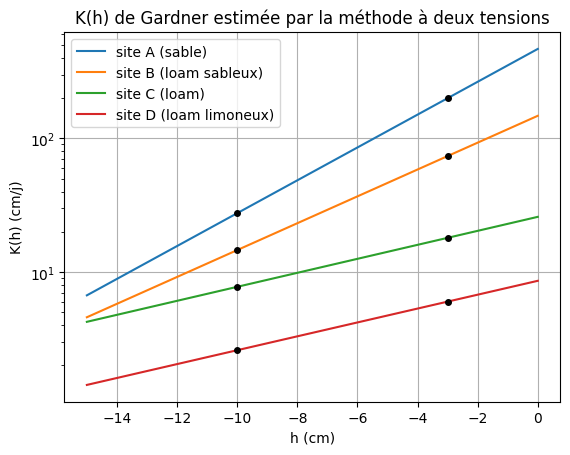

In [20]:
Ks_CP = []
lambda_c_MvG = []
K10_Gardner = []
K10_MvG = []
for i in range(len(inf)):
    texture = inf.loc[i, "texture"]
    s = sols.loc[texture]
    Ks_CP.append(s["Ks"])
    lambda_c_MvG.append(s["lambda_c"])
    # K(-10 cm) selon Gardner (terrain) et selon Mualem–van Genuchten (catalogue)
    K10_Gardner.append(inf.loc[i, "Ks"] * np.exp(inf.loc[i, "alpha_G"] * (-10)))
    K10_MvG.append(vg_K(-10, s["thr"], s["ths"], s["alpha"], s["n"], s["Ks"]))
inf["Ks_CarselParrish"] = Ks_CP
inf["lambda_c_MvG"] = lambda_c_MvG
inf["K10_Gardner"] = K10_Gardner
inf["K10_MvG"] = K10_MvG
colonnes = ["site", "texture", "Ks", "Ks_CarselParrish", "lambda_c", "lambda_c_MvG", "K10_Gardner", "K10_MvG"]
print(inf[colonnes].round(3))

# courbes K(h) de Gardner estimées sur chaque site, avec les deux points de mesure
h_grille = np.linspace(-15, 0, 50)
plt.figure()
for i in range(len(inf)):
    Ks_site = inf.loc[i, "Ks"]
    aG_site = inf.loc[i, "alpha_G"]
    etiquette = "site " + inf.loc[i, "site"] + " (" + inf.loc[i, "texture"] + ")"
    plt.semilogy(h_grille, Ks_site * np.exp(aG_site * h_grille), label=etiquette)
    plt.plot([h1, h2], [Ks_site * np.exp(aG_site * h1), Ks_site * np.exp(aG_site * h2)], "ko", markersize=4)
plt.xlabel("h (cm)")
plt.ylabel("K(h) (cm/j)")
plt.title("K(h) de Gardner estimée par la méthode à deux tensions")
plt.legend()
plt.grid(True)
plt.show()

**Commentaire (instructeur).** Le facteur géométrique $1 + 4/(\pi r \alpha_G)$ vaut 1,4 (sable) à 2,1 (loam limoneux) : négliger la capillarité latérale
surestimerait $K$ de 40 à 110 %. Les $K_s$ « de terrain » diffèrent du catalogue d'un facteur 0,7 à 1,4 (variabilité typique,
souvent bien plus au champ) alors que $\lambda_c$ est retrouvée à ±20 % : la longueur capillaire est une propriété plus stable que $K_s$.
Rappel : ces mesures excluent les macropores ($h_0 < 0$) ; $K_s$ estimée par extrapolation à $h = 0$ est celle de la matrice.

## Exercice 5 — Bonus — solution analytique de Gardner pour l'évaporation maximale  *(≈ facultatif)*

Pour $K = K_s e^{\alpha_G h}$, on montre que $L_{max}(q) = \dfrac{1}{\alpha_G}\ln\!\left(1 + \dfrac{K_s}{q}\right)$ et donc
$e_{max}(L) = \dfrac{K_s}{e^{\alpha_G L} - 1}$. Calculer $e_{max}$ du loam ($K_s = 24{,}96$ cm/j, $\alpha_G = 1/\lambda_c$) pour
$L = 30, 50, 100$ cm et comparer aux valeurs MvG de l'exercice 2. D'où vient l'écart ?

**e_max de Gardner et de Mualem–van Genuchten**

L =  30 cm : e_max Gardner = 3.314e-01 cm/j, e_max MvG = 1.405e+00 cm/j
L =  50 cm : e_max Gardner = 1.819e-02 cm/j, e_max MvG = 4.027e-01 cm/j
L = 100 cm : e_max Gardner = 1.324e-05 cm/j, e_max MvG = 5.447e-02 cm/j


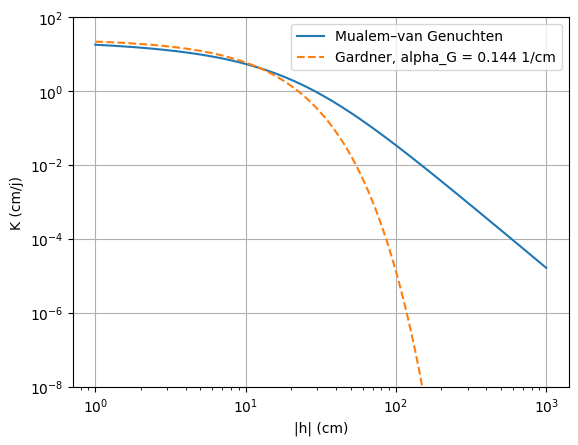

In [21]:
# paramètres du loam ; alpha_G = 1 / lambda_c (exercice 1)
thr = sols.loc["loam", "thr"]
ths = sols.loc["loam", "ths"]
alpha = sols.loc["loam", "alpha"]
n = sols.loc["loam", "n"]
Ks = sols.loc["loam", "Ks"]
aG = sols.loc["loam", "alpha_G"]

# L_max = intégrale de dh / (1 + (q/Ks) e^(-aG h)) ; avec u = e^(aG h) : L_max = ln(1 + Ks/q) / aG, donc e_max = Ks / (e^(aG L) - 1)
for L in [30, 50, 100]:
    e_gardner = Ks / (np.exp(aG * L) - 1)
    e_mvg = brentq(ecart_L, 1e-12, Ks, args=(L, thr, ths, alpha, n, Ks))
    print(f"L = {L:3d} cm : e_max Gardner = {e_gardner:.3e} cm/j, e_max MvG = {e_mvg:.3e} cm/j")

# comparaison des deux K(h) sur la gamme utile
h_abs = np.logspace(0, 3, 200)
plt.figure()
plt.loglog(h_abs, vg_K(-h_abs, thr, ths, alpha, n, Ks), label="Mualem–van Genuchten")
plt.loglog(h_abs, Ks * np.exp(-aG * h_abs), "--", label=f"Gardner, alpha_G = {aG:.3f} 1/cm")
plt.ylim(1e-8, 1e2)
plt.xlabel("|h| (cm)")
plt.ylabel("K (cm/j)")
plt.legend()
plt.grid(True)
plt.show()

**Commentaire (instructeur).** Le modèle exponentiel sous-estime $e_{max}$ de plusieurs ordres de grandeur dès que $L > 50$ cm : sa conductivité décroît
beaucoup plus vite que la loi de puissance de MvG ($K \propto |h|^{-3{,}4}$ pour le loam loin de la saturation), or c'est la
queue de $K(h)$ dans le sol sec qui contrôle la remontée capillaire. Gardner (1958) utilisait d'ailleurs $K = a/(b + |h|^n)$
pour ce problème, pas l'exponentielle.

## Pour aller plus loin

* Reprendre l'exercice 2 avec la nappe à 50 cm et à 150 cm : comment évolue $h$ en surface pour $q = -1$ cm/j ?
* Dans HYDRUS-1D, remplacer le flux imposé de $+0{,}03$ cm/j par $+0{,}06$ cm/j ($> e_{max}$) et observer `RUN_INF.OUT`.
* Réaliser l'essai à trois tensions ($-3$, $-6$, $-10$ cm) et vérifier la linéarité de $\ln Q$ en fonction de $h_0$.